<a href="https://colab.research.google.com/github/hoin1357/MachineLearning/blob/main/2%EC%B0%A8%20%EA%B3%BC%EC%A0%9C/2%EC%B0%A8%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 서울대공원 방문객 예측
## 2차 수정 코드 관점 변경 보고서

### 1. 변경 배경

기존 2차 수정 코드는 전체 예측 오차 감소와 한산한 날짜 추천에 초점이 맞춰져 있었다.
하지만 실제 서비스의 주요 사용자가 “사람이 많이 몰리는 날짜에 방문할 수 밖에 없는 직장인 가정”으로 설정하면,
모델의 핵심 목표도 한산일 탐색이 아니라 혼잡일 예측 정확도 향상으로 바뀌어야 한다.

> 즉, 이번 변경은 단순한 지표 수정이 아니라
> 모델이 중요하게 학습해야 하는 대상 자체를 한산일 → 혼잡일로 전환하는 것이다.

### 2. 기존 2차 수정 코드의 한계

[기존 방식과 한계]
- 추천 관점: Precision@K로 한산일 추천 평가 → 혼잡일 예측 목적과 맞지 않음
- 타깃 변환: log1p 사용 → 큰 방문객 수가 눌려 피크 예측에 불리
- 학습 중요도: 모든 날짜 동일 취급 → 혼잡일 오차를 특별히 중요하게 반영하지 못함
- 모델 성격: 전체적으로 무난한 예측 → 붐비는 날을 놓치지 않는 데 약할 수 있음

핵심 문제
- 기존 구조는 “한산한 날을 잘 찾는 모델”에 더 가까움
- 현재 서비스 목적은 “혼잡한 날을 정확히 맞추는 모델”임

### 3. 변경 내용 요약

[기존 → 변경]
- 평가 지표:
  MAE, RMSE, MAPE, R², Precision@K(한산일)
  → MAE, RMSE, MAPE, R² + Precision@K / Recall@K / NDCG@K(혼잡일)

- 타깃 변환:
  log1p 적용
  → 원래 방문객 수 스케일 유지

- 학습 방식:
  동일 가중치 학습
  → 혼잡일에 높은 sample_weight 부여

- 파라미터 선택:
  전체 오차 중심
  → 혼잡일 성능 중심 우선 선택

- 변수 설계:
  전체 방문객 수 설명 중심
  → 피크 발생 요인 설명 변수 강화

-데이터 추가:
 날씨데이터와 축제 데이터 추가
→방문자 수에 큰 영향을 주는 데이터 추가

-모델 변환:
 catboost 단일 모델
 →CatBoostClassifier -> CatBoostRegressor 의 형태로 변화



### 3-1. 평가 관점 변경

기존
- MAE
- RMSE
- MAPE
- R²
- Precision@K (한산일 기준)

변경
- MAE
- RMSE
- MAPE
- R²
- Precision@K (혼잡일 기준)
- Recall@K (혼잡일 기준)
- NDCG@K (혼잡일 순위 기준)

변경 이유
기존 4개의 지표는 그대로 놔두고, 사람이 적은 날에 높은 가중치를 둔 Precision@K 대신,
Precision@K ,ecall@K ,DCG@K 을 넣었다. 세 지표 모두 다 혼잡일을 잘 맟춘것에 높은 점수를 주기에
관점 변화에 따른 평가지표 변경이다.

###3-1-2 평가지표 설명

- Precision@K (혼잡일 기준): 모델에서는 예측 혼잡도 상위 15일과 실제 혼자도 상위 15일을 비교했다.(정확도 중심)
- Recall@K (혼잡일 기준): 예측 혼잡도 15일과 , 실제 혼잡도 상위 20%를 뽑아 포함된 날짜 비율을 계산했다.
                                 혼잡일을 맞춘 정확도 보다, 전체적으로 얼마나 맟췄는지를 보는 지표이다.(포착률 중심)
- NDCG@K (혼잡일 순위 기준): 마찬가지로 15일을 설정하고 랭킹을 매겨 정확도의 품질을 평가했다.


### 3-2. 타깃 변환 방식 변경

기존
- log1p(방문객 수)

변경
- 원래 방문객 수 그대로 사용

변경 이유
log1p는 큰 값을 작아지므로 전체 안정성은 좋아질 수 있다.
하지만 혼잡일 예측에서는 큰 방문객 수 차이를 민감하게 반영하는 것이 더 중요하다.

정리
- 기존: 사람이 안오는날 안정성 강화
- 변경: 사람 많은 날 예측 강화

### 3-3. 학습 가중치 부여 방식 추가

기존
- 모든 날짜를 같은 중요도로 학습

변경
- 혼잡일에 더 큰 sample_weight 부여.오차에 대한 벌 점수가 커지므로 혼잡도가 높은날을 더 잘 반영하게 됨.


예시
- 상위 10% 방문객 날짜 → 높은 가중치
- 상위 20% 방문객 날짜 → 중간 가중치
- 나머지 날짜 → 기본 가중치

변경 이유
데이터를 직접 살펴보던 중, 주단위로 일정하게 주말마다 사용자가 폭증하는 것을 확인하였고, 공휴일이나 주말같은 요인이
이용자수의 증가에 큰 영향을 주는 것이 확인되었음. 또한 서울대공원 공식 홈페이지에서도 주말,공휴일에는 많은 인원을
가정하고 있는것을 확인하였음.

목표
- 전체 평균 성능보다 혼잡일 성능을 우선 학습

### 3-4. 성능지표 선택 기준 변경

기존 선택 기준
- 전체 MAE
- 전체 RMSE
- Precision@10 중심

변경 선택 기준
1. 혼잡일 기준 Precision@K
2. 혼잡일 기준 NDCG@K
3. 전체 RMSE 또는 MAE

변경 이유
평가 지표만 바꾸고 성능지표를 그대로 두면,
최종적으로는 여전히 평균적인 날에 강한 모델이 선택될 가능성이 크다.

### 3-5. 혼잡일 설명 변수 강화

기존
- 공휴일
- 행사
- 주말
- 날씨
- 지연값 등 사용

변경
혼잡일과 직접 연결되는 파생 변수를 더 강조하거나 추가

강화 대상 변수 예시
- 연휴 여부
- 공휴일 전날 / 당일 / 다음날
- 행사 시작일 / 종료일
- 행사 + 주말 동시 발생 여부
- 성수기 플래그 (예: 5월, 10월)
- 맑은 날씨 + 주말 결합 효과

변경 이유
혼잡일은 보통 하나의 요인보다 여러 외부 요인이 겹칠 때 발생하는 경우가 많다.

즉, 평균적인 날짜 설명보다 피크를 설명하는 변수 설계가 더 중요하다.따라서 중요변수가 겹치거나,
중요변수와 값이 가까운 날 등을 예측값에 반영하기 위해 변수를 변경했다.

###3-6 공휴일 라이브러리 변경
 기존
 - holydays

변경
 - holydayskr

변경이유
혼잡한 날의 중요성을 알게 됨에 따라, 기존 holydats 라이브러리에서 한국의 공휴일 특징이 더 잘 반영되어있는
holydaykr로 변경함.

###3-7 모델 변경
기존
-CatBoostClassifier 단일 모델

변경
-CatBoostClassifier -> CatBoostRegressor 이중적용

변경이유
 공휴일과 연휴같은 날의 중요성을 높힘에 따라, 모델의 사용방식에도 변화를 줬다.
 CatBoostClassifier 모델로 혼잡도가 높은 날은 우선적으로 분류하고, 이후에 분류한 값을 참고해서
 기존 CatBoostRegressor 모델로 방문자 수를 예측하는 것이 더 효과적일 것이라고 생각했다.

###3-8 변수 추가
기존
-서울대공원 인원 데이터 (출처:https://data.seoul.go.kr/dataList/OA-15386/F/1/datasetView.do)

변경
-기존 데이터에 추가로 날씨 데이터와 축제 데이터 추가
(출처:https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36, https://grandpark.seoul.go.kr/munhwa/munhwaList/ko/S001005001004.do)
### 4. 최종 정리

이번 관점 변경의 핵심은 기존 2차 수정 코드 구조를 버리는 것이 아니다.
기존의 CatBoost 기반 구조와 데이터 전처리 흐름은 유지하되,
그 안의 학습 목표와 평가 기준을 서비스 목적에 맞게 다시 정렬하는 것이다.

재설계 핵심 방향
- 한산일 추천 지표 제거
- 혼잡일 중심 랭킹 지표 도입
- 로그 변환 제거
- 혼잡일 가중치 학습 적용
- 하이퍼파라미터 선택 기준을 혼잡일 중심으로 변경
- 피크 설명 변수 강화




# 성능지표 개선 결과

## 변경 전
- **MAE**: 3022.03  
- **RMSE**: 4558.66  
- **MAPE**: 127.72%  
- **R²**: 0.7384  

- **Precision@15**: 0.4667  
- **Recall@15**: 0.4667  
- **NDCG@15**: 0.3598  

## 변경 후
- **MAE**: 2997.42  
- **RMSE**: 4218.03  
- **MAPE**: 210.15%  
- **R²**: 0.7760  

- **Precision@15**: 0.8667  
- **Recall@15**: 0.7368  
- **NDCG@15**: 0.9385  

---

## 각 변수 설명

- **년**: 해마다 운영 조건이나 전체 방문 추세가 달라질 수 있어서 넣었습니다.  
- **월**: 계절성과 성수기·비수기 차이를 반영합니다.  
- **일**: 월초·월말 같은 월 내 위치 효과를 반영합니다.  
- **요일번호**: 평일과 주말 패턴 차이를 세밀하게 반영합니다. (예: 월요일, 금요일 등)  
- **주말여부**: 가족 단위 방문 증가가 큰 주말 효과를 직접 반영합니다.  
- **분기**: 큰 계절 블록 차이를 반영합니다.  
- **연중일수**: 1년 중 현재 시점이 어디인지 세밀하게 표현합니다.  
- **연중주차**: 주 단위 반복성과 연휴 전후 효과를 반영합니다. (예: 연휴, 공휴일 같은 주 단위 반복성 포착)  
- **시작후경과일**: 장기 추세 변화가 있는지 보기 위해 넣었습니다.  
- **월_sin**: 월의 순환성을 부드럽게 표현합니다.  
- **월_cos**: `월_sin`과 함께 월의 원형 계절성을 완성합니다.  
- **연중일수_sin**: 일 단위 계절 반복을 연속적으로 표현합니다.  
- **연중일수_cos**: `연중일수_sin`과 함께 1년 주기 구조를 표현합니다.  
- **공휴일여부**: 공휴일은 방문객 수를 크게 바꾸는 핵심 변수입니다.  
- **주말또는공휴일여부**: 쉬는 날 전체 효과를 한 번 더 안정적으로 전달합니다.  
- **평균기온**: 너무 춥거나 너무 더우면 방문 패턴이 바뀌므로 중요합니다.  
- **일강수량**: 비 오는 날 방문 감소 가능성을 반영합니다.  
- **강수여부**: 비의 유무 자체가 의사결정에 큰 영향을 줄 수 있어 추가했습니다.  
- **폭우여부**: 단순 비보다 강한 억제 효과를 별도로 반영합니다.  
- **한파일수**: 매우 추운 날 야외활동 감소를 반영합니다.  
- **무더위일수**: 매우 더운 날 외출 감소 또는 시간대 이동을 반영합니다.  
- **행사여부**: 축제나 특별행사가 있으면 방문객이 급증할 수 있습니다.  
- **진행행사수**: 동시에 여러 행사가 겹칠 경우 효과가 더 커질 수 있습니다.  
- **지연값_1**: 전날 방문객 수로 단기 연속성을 반영합니다.  
- **지연값_7**: 1주 전 같은 요일 효과를 반영합니다.  
- **지연값_30**: 한 달 전 수준을 반영해 월 단위 흐름을 잡습니다.  
- **지연값_365**: 전년 동시기 계절성을 직접 반영합니다.  
- **이동평균_7**: 최근 1주 평균 흐름을 반영합니다.  
- **이동평균_30**: 최근 한 달 평균 수준을 반영합니다.  
- **이동표준편차_7**: 최근 1주간 변동성이 큰지 확인합니다.  
- **이동표준편차_30**: 최근 한 달간 안정성 또는 불안정성을 반영합니다.  
- **혼잡일확률**: 1단계 분류기가 판단한 “붐빌 가능성”으로, 2단계 회귀가 피크 가능성을 직접 참고하게 합니다.  
- **혼잡일예측라벨**: 혼잡일인지 아닌지의 이진 신호를 추가해 회귀 모델이 구간별 패턴을 더 쉽게 분리하도록 돕습니다.  

결손 구간 요약
2016-12-18 ~ 2017-03-29 : 102일
2019-09-07 ~ 2019-09-07 : 1일

상위 하이퍼파라미터 후보 5개
 depth  learning_rate  iterations  l2_leaf_reg  min_data_in_leaf  random_strength  cv_busy_precision_at_15  cv_busy_recall_at_15  cv_busy_ndcg_at_15  cv_busy_mae_top20    cv_mae   cv_rmse
     4         0.0300         800       8.0000                 5           1.0000                   0.7556                0.5556              0.8872          4042.2222 1598.7167 3047.4014
     4         0.0300         800       8.0000                15           1.0000                   0.7556                0.5556              0.8872          4042.2222 1598.7167 3047.4014
     4         0.0300         500       3.0000                 5           1.0000                   0.7556                0.5556              0.8867          3969.3194 1618.9139 3029.9112
     4         0.0300         500       3.0000                15           1.0000                   0.7556                0.5556              0.8867          396

/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4213628208.py:708: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt

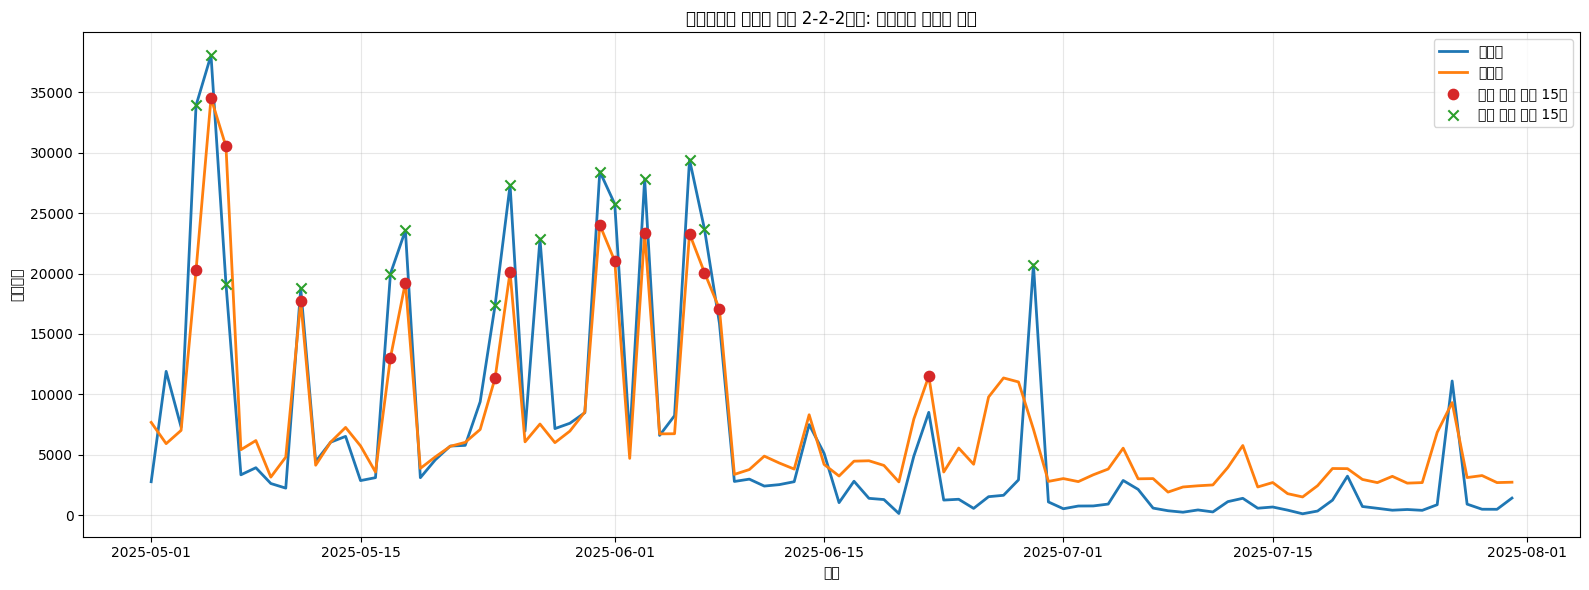

결과표를 저장했습니다: second_improvement_two_stage_busy_focus_results.csv

학습 데이터 중앙값으로 채운 특징 수: 31개


In [ ]:
import subprocess
import sys
from itertools import product
from pathlib import Path
import re


def install_packages() -> None:
    required_packages = ["catboost", "holidayskr"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])

    if sys.platform.startswith("linux"):
        subprocess.run(["apt-get", "update", "-y"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.run(
            ["apt-get", "install", "-y", "fonts-nanum"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        subprocess.run(["fc-cache", "-fv"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


install_packages()

import holidayskr
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score, r2_score


def set_korean_font() -> None:
    preferred_fonts = ["NanumGothic", "Malgun Gothic", "AppleGothic"]
    available_fonts = {font.name for font in fm.fontManager.ttflist}

    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()


DATA_ROOT = Path(".")
VISITORS_FILE = DATA_ROOT / "seoul_grand_park_daily_visitors_with_missing_dates.csv"
# 오류 수정: '날씨 데이터' 폴더가 아닌 현재 경로에서 연도별 CSV를 찾도록 수정
WEATHER_DIR = DATA_ROOT
EVENTS_FILE = DATA_ROOT / "seoul_grand_park_events_2015_2025_aug.csv"

EVAL_START_DATE = pd.Timestamp("2025-05-01")
BUSY_K = 15
BUSY_RECALL_RATIO = 0.20
STAGE1_BUSY_LABEL_RATIO = 0.15
TOP_10_WEIGHT = 4.0
TOP_20_WEIGHT = 2.0

BASELINE_METRICS = {
    "MAE": 3022.03,
    "RMSE": 4558.66,
    "MAPE": 127.72,
    "R2": 0.7384,
}

STAGE1_CLASSIFIER_PARAMS = {
    "loss_function": "Logloss",
    "depth": 6,
    "learning_rate": 0.05,
    "iterations": 500,
    "l2_leaf_reg": 3.0,
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False,
}


def load_visitors(file_path: Path) -> pd.DataFrame:
    visitors = pd.read_csv(file_path)
    visitors["일자"] = pd.to_datetime(visitors["일자"].astype(str))
    visitors = visitors.sort_values("일자").reset_index(drop=True)
    return visitors


def load_weather(weather_dir: Path) -> pd.DataFrame:
    weather_frames = []
    # 연도 형식(20xx.csv)의 파일만 필터링하여 읽어오도록 수정
    for csv_path in sorted(weather_dir.glob("20*.csv")):
        yearly_weather = pd.read_csv(csv_path, encoding="cp949")
        weather_frames.append(yearly_weather)

    if not weather_frames:
        raise FileNotFoundError(f"{weather_dir} 경로에서 날씨 데이터 CSV 파일을 찾을 수 없습니다.")

    weather = pd.concat(weather_frames, ignore_index=True)

    weather["일자"] = pd.to_datetime(weather["일시"])
    weather["평균기온"] = pd.to_numeric(weather["평균기온(°C)"], errors="coerce")
    weather["일강수량"] = pd.to_numeric(weather["일강수량(mm)"], errors="coerce")

    weather["일강수량"] = weather["일강수량"].fillna(0.0)
    weather["평균기온"] = weather["평균기온"].interpolate(limit_direction="both")

    weather["강수여부"] = (weather["일강수량"] > 0).astype(int)
    weather["폭우여부"] = (weather["일강수량"] >= 10).astype(int)
    weather["한파일수"] = (weather["평균기온" ] <= 0).astype(int)
    weather["무더위일수"] = (weather["평균기온"] >= 30).astype(int)

    weather_columns = ["일자", "평균기온", "일강수량", "강수여부", "폭우여부", "한파일수", "무더위일수"]
    weather = weather[weather_columns].sort_values("일자").reset_index(drop=True)
    return weather


def parse_event_period(event_text: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    date_matches = re.findall(r"(\d{4}\.\d{2}\.\d{2})", event_text)
    if not date_matches:
        raise ValueError(f"행사 날짜를 찾을 수 없습니다: {event_text}")

    start_date = pd.to_datetime(date_matches[0], format="%Y.%m.%d")
    end_date = pd.to_datetime(date_matches[1], format="%Y.%m.%d") if len(date_matches) > 1 else start_date
    return start_date, end_date


def load_events(file_path: Path) -> pd.DataFrame:
    events = pd.read_csv(file_path)
    event_daily_records = []

    for _, event_row in events.iterrows():
        event_text = str(event_row["행사이름 - 날짜"])
        start_date, end_date = parse_event_period(event_text)
        for current_date in pd.date_range(start_date, end_date, freq="D"):
            event_daily_records.append({"일자": current_date, "행사이름": event_text})

    event_daily = pd.DataFrame(event_daily_records)
    if event_daily.empty:
        return pd.DataFrame({"일자": [], "행사여부": [], "진행행사수": []})

    event_daily = (
        event_daily.groupby("일자", as_index=False)
        .agg(진행행사수=("행사이름", "count"))
        .sort_values("일자")
        .reset_index(drop=True)
    )
    event_daily["행사여부"] = (event_daily["진행행사수"] > 0).astype(int)
    return event_daily[["일자", "행사여부", "진행행사수"]]


def add_calendar_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    dataframe = dataframe.copy()

    dataframe["년"] = dataframe["일자"].dt.year
    dataframe["월"] = dataframe["일자"].dt.month
    dataframe["일"] = dataframe["일자"].dt.day
    dataframe["요일번호"] = dataframe["일자"].dt.dayofweek
    dataframe["주말여부"] = (dataframe["요일번호"] >= 5).astype(int)
    dataframe["분기"] = dataframe["일자"].dt.quarter
    dataframe["연중일수"] = dataframe["일자"].dt.dayofyear
    dataframe["연중주차"] = dataframe["일자"].dt.isocalendar().week.astype(int)
    dataframe["시작후경과일"] = (dataframe["일자"] - dataframe["일자"].min()).dt.days
    dataframe["월_sin"] = np.sin(2 * np.pi * dataframe["월"] / 12)
    dataframe["월_cos"] = np.cos(2 * np.pi * dataframe["월"] / 12)
    dataframe["연중일수_sin"] = np.sin(2 * np.pi * dataframe["연중일수"] / 365.25)
    dataframe["연중일수_cos"] = np.cos(2 * np.pi * dataframe["연중일수"] / 365.25)

    dataframe["공휴일여부"] = dataframe["일자"].dt.strftime("%Y-%m-%d").map(
        lambda date_text: int(holidayskr.is_holiday(date_text))
    )
    dataframe["주말또는공휴일여부"] = (
        (dataframe["주말여부"] == 1) | (dataframe["공휴일여부" ] == 1)
    ).astype(int)

    return dataframe


def summarize_missing_blocks(visitors: pd.DataFrame) -> list[tuple[pd.Timestamp, pd.Timestamp, int]]:
    missing_dates = visitors.loc[visitors["방문인원수"].isna(), "일자"].sort_values().reset_index(drop=True)
    if missing_dates.empty:
        return []

    missing_blocks = []
    block_start = missing_dates.iloc[0]
    previous_date = missing_dates.iloc[0]

    for current_date in missing_dates.iloc[1:]:
        if (current_date - previous_date).days == 1:
            previous_date = current_date
            continue
        missing_blocks.append((block_start, previous_date, (previous_date - block_start).days + 1))
        block_start = current_date
        previous_date = current_date

    missing_blocks.append((block_start, previous_date, (previous_date - block_start).days + 1))
    return missing_blocks


def fill_missing_visitors(
    visitors: pd.DataFrame,
    weather: pd.DataFrame,
    events: pd.DataFrame,
    eval_start_date: pd.Timestamp,
) -> tuple[pd.DataFrame, list[tuple[pd.Timestamp, pd.Timestamp, int]]]:
    filled_visitors = visitors.copy()
    missing_blocks = summarize_missing_blocks(filled_visitors)

    filled_visitors = filled_visitors.merge(weather, on="일자", how="left")
    filled_visitors = filled_visitors.merge(events, on="일자", how="left")
    filled_visitors["행사여부"] = filled_visitors["행사여부"].fillna(0).astype(int)
    filled_visitors["진행행사수"] = filled_visitors["진행행사수"].fillna(0).astype(int)
    filled_visitors = add_calendar_features(filled_visitors)

    single_missing_date = pd.Timestamp("2019-09-07")
    yearly_mask = (filled_visitors["년"] == 2019) & filled_visitors["방문인원수"].notna()
    yearly_average = filled_visitors.loc[yearly_mask, "방문인원수"].mean()
    weekday_code = int(single_missing_date.dayofweek)
    weekday_average = filled_visitors.loc[
        yearly_mask & (filled_visitors["요일번호"] == weekday_code),
        "방문인원수",
    ].mean()
    filled_visitors.loc[filled_visitors["일자"] == single_missing_date, "방문인원수"] = round(
        (yearly_average + weekday_average) / 2
    )

    imputation_features = [
        "년",
        "월",
        "일",
        "요일번호",
        "주말여부",
        "분기",
        "연중일수",
        "연중주차",
        "시작후경과일",
        "월_sin",
        "월_cos",
        "연중일수_sin",
        "연중일수_cos",
        "공휴일여부",
        "주말또는공휴일여부",
        "평균기온",
        "일강수량",
        "강수여부",
        "폭우여부",
        "한파일수",
        "무더위일수",
        "행사여부",
        "진행행사수",
    ]

    long_gap_mask = filled_visitors["일자"].between(pd.Timestamp("2016-12-18"), pd.Timestamp("2017-03-29"))
    train_mask = filled_visitors["방문인원수"].notna() & (filled_visitors["일자"] < eval_start_date) & (~long_gap_mask)

    imputation_train_x = filled_visitors.loc[train_mask, imputation_features]
    imputation_train_y = filled_visitors.loc[train_mask, "방문인원수"]
    imputation_target_x = filled_visitors.loc[long_gap_mask, imputation_features]

    imputation_model = CatBoostRegressor(
        loss_function="RMSE",
        depth=6,
        learning_rate=0.05,
        iterations=700,
        l2_leaf_reg=5.0,
        min_data_in_leaf=5,
        random_strength=1.0,
        verbose=False,
        random_seed=42,
        allow_writing_files=False,
    )
    imputation_model.fit(imputation_train_x, imputation_train_y)

    predicted_gap_values = imputation_model.predict(imputation_target_x)
    predicted_gap_values = np.maximum(np.round(predicted_gap_values), 0).astype(int)
    filled_visitors.loc[long_gap_mask, "방문인원수"] = predicted_gap_values
    filled_visitors["방문인원수"] = filled_visitors["방문인원수"].round().astype(int)

    helper_columns = [
        "평균기온",
        "일강수량",
        "강수여부",
        "폭우여부",
        "한파일수",
        "무더위일수",
        "행사여부",
        "진행행사수",
        "년",
        "월",
        "일",
        "요일번호",
        "주말여부",
        "분기",
        "연중일수",
        "연중주차",
        "시작후경과일",
        "월_sin",
        "월_cos",
        "연중일수_sin",
        "연중일수_cos",
        "공휴일여부",
        "주말또는공휴일여부",
    ]
    filled_visitors = filled_visitors.drop(columns=helper_columns)
    return filled_visitors, missing_blocks


def build_features(visitors: pd.DataFrame, weather: pd.DataFrame, events: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    feature_data = visitors.copy()
    feature_data = feature_data.merge(weather, on="일자", how="left")
    feature_data = feature_data.merge(events, on="일자", how="left")

    feature_data["행사여부"] = feature_data["행사여부"].fillna(0).astype(int)
    feature_data["진행행사수"] = feature_data["진행행사수"].fillna(0).astype(int)
    feature_data = add_calendar_features(feature_data)

    feature_data["지연값_1"] = feature_data["방문인원수"].shift(1)
    feature_data["지연값_7"] = feature_data["방문인원수"].shift(7)
    feature_data["지연값_30"] = feature_data["방문인원수"].shift(30)
    feature_data["지연값_365"] = feature_data["방문인원수"].shift(365)

    previous_visitors = feature_data["방문인원수"].shift(1)
    feature_data["이동평균_7"] = previous_visitors.rolling(window=7).mean()
    feature_data["이동평균_30"] = previous_visitors.rolling(window=30).mean()
    feature_data["이동표준편차_7"] = previous_visitors.rolling(window=7).std()
    feature_data["이동표준편차_30"] = previous_visitors.rolling(window=30).std()

    feature_columns = [
        "년",
        "월",
        "일",
        "요일번호",
        "주말여부",
        "분기",
        "연중일수",
        "연중주차",
        "시작후경과일",
        "월_sin",
        "월_cos",
        "연중일수_sin",
        "연중일수_cos",
        "공휴일여부",
        "주말또는공휴일여부",
        "평균기온",
        "일강수량",
        "강수여부",
        "폭우여부",
        "한파일수",
        "무더위일수",
        "행사여부",
        "진행행사수",
        "지연값_1",
        "지연값_7",
        "지연값_30",
        "지연값_365",
        "이동평균_7",
        "이동평균_30",
        "이동표준편차_7",
        "이동표준편차_30",
    ]
    return feature_data, feature_columns


def fill_features_with_train_medians(
    train_x: pd.DataFrame,
    target_x: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    train_medians = train_x.median(numeric_only=True)
    filled_train_x = train_x.fillna(train_medians)
    filled_target_x = target_x.fillna(train_medians)
    return filled_train_x, filled_target_x, train_medians


def make_busy_sample_weights(target_values: pd.Series) -> np.ndarray:
    target_values = target_values.reset_index(drop=True)
    sample_count = len(target_values)
    top_10_count = max(1, int(np.ceil(sample_count * 0.10)))
    top_20_count = max(top_10_count, int(np.ceil(sample_count * 0.20)))

    weights = pd.Series(1.0, index=target_values.index, dtype=float)
    weights.loc[target_values.nlargest(top_20_count).index] = TOP_20_WEIGHT
    weights.loc[target_values.nlargest(top_10_count).index] = TOP_10_WEIGHT
    return weights.to_numpy()


def make_stage1_busy_labels(target_values: pd.Series, busy_ratio: float = STAGE1_BUSY_LABEL_RATIO) -> pd.Series:
    target_values = target_values.reset_index(drop=True)
    busy_count = max(1, int(np.ceil(len(target_values) * busy_ratio)))
    labels = pd.Series(0, index=target_values.index, dtype=int)
    labels.loc[target_values.nlargest(busy_count).index] = 1
    return labels


def fit_stage1_classifier(train_x: pd.DataFrame, train_y: pd.Series) -> CatBoostClassifier:
    busy_labels = make_stage1_busy_labels(train_y)
    classifier = CatBoostClassifier(**STAGE1_CLASSIFIER_PARAMS)
    classifier.fit(train_x, busy_labels)
    return classifier


def append_stage1_outputs(classifier: CatBoostClassifier, base_x: pd.DataFrame) -> pd.DataFrame:
    busy_probability = classifier.predict_proba(base_x)[:, 1]
    busy_label = (busy_probability >= 0.5).astype(int)

    augmented_x = base_x.copy()
    augmented_x["혼잡일확률"] = busy_probability
    augmented_x["혼잡일예측라벨"] = busy_label
    return augmented_x


def precision_at_k_busy(actual_values: pd.Series, predicted_values: pd.Series, k: int) -> float:
    actual_values = actual_values.reset_index(drop=True)
    predicted_values = predicted_values.reset_index(drop=True)
    top_k = max(1, min(k, len(actual_values)))

    predicted_busy_indices = set(predicted_values.nlargest(top_k).index)
    actual_busy_indices = set(actual_values.nlargest(top_k).index)
    return len(predicted_busy_indices & actual_busy_indices) / top_k


def recall_at_k_busy(actual_values: pd.Series, predicted_values: pd.Series, k: int, busy_ratio: float) -> float:
    actual_values = actual_values.reset_index(drop=True)
    predicted_values = predicted_values.reset_index(drop=True)
    top_k = max(1, min(k, len(actual_values)))
    actual_busy_count = max(1, int(np.ceil(len(actual_values) * busy_ratio)))

    predicted_busy_indices = set(predicted_values.nlargest(top_k).index)
    actual_busy_indices = set(actual_values.nlargest(actual_busy_count).index)
    return len(predicted_busy_indices & actual_busy_indices) / actual_busy_count


def ndcg_at_k_busy(actual_values: pd.Series, predicted_values: pd.Series, k: int) -> float:
    actual_array = actual_values.reset_index(drop=True).to_numpy(dtype=float)
    predicted_array = predicted_values.reset_index(drop=True).to_numpy(dtype=float)
    top_k = max(1, min(k, len(actual_array)))
    return float(ndcg_score([actual_array], [predicted_array], k=top_k))


def mae_on_actual_top_ratio(actual_values: pd.Series, predicted_values: np.ndarray, busy_ratio: float) -> float:
    actual_values = actual_values.reset_index(drop=True)
    rounded_predictions = pd.Series(np.maximum(np.round(predicted_values), 0).astype(int))
    actual_busy_count = max(1, int(np.ceil(len(actual_values) * busy_ratio)))
    actual_busy_indices = actual_values.nlargest(actual_busy_count).index
    return float(mean_absolute_error(actual_values.loc[actual_busy_indices], rounded_predictions.loc[actual_busy_indices]))


def create_expanding_folds(row_count: int, validation_size: int = 120, n_splits: int = 3) -> list[tuple[np.ndarray, np.ndarray]]:
    folds = []
    validation_starts = [row_count - validation_size * multiplier for multiplier in range(n_splits, 0, -1)]

    for validation_start in validation_starts:
        validation_end = validation_start + validation_size
        if validation_start <= 365:
            continue
        train_indices = np.arange(0, validation_start)
        validation_indices = np.arange(validation_start, min(validation_end, row_count))
        if len(validation_indices) == validation_size:
            folds.append((train_indices, validation_indices))

    return folds


def evaluate_predictions(actual_values: pd.Series, predicted_values: np.ndarray, k: int) -> dict[str, float]:
    rounded_predictions = np.maximum(np.round(predicted_values), 0).astype(int)
    mae_value = mean_absolute_error(actual_values, rounded_predictions)
    rmse_value = np.sqrt(mean_squared_error(actual_values, rounded_predictions))
    mape_value = np.mean(
        np.where(actual_values != 0, np.abs((actual_values - rounded_predictions) / actual_values) * 100, 0)
    )
    r2_value = r2_score(actual_values, rounded_predictions)
    rounded_prediction_series = pd.Series(rounded_predictions)
    busy_precision_value = precision_at_k_busy(actual_values.reset_index(drop=True), rounded_prediction_series, k)
    busy_recall_value = recall_at_k_busy(actual_values.reset_index(drop=True), rounded_prediction_series, k, BUSY_RECALL_RATIO)
    busy_ndcg_value = ndcg_at_k_busy(actual_values.reset_index(drop=True), rounded_prediction_series, k)
    busy_top_mae_value = mae_on_actual_top_ratio(actual_values.reset_index(drop=True), rounded_predictions, BUSY_RECALL_RATIO)

    return {
        "MAE": float(mae_value),
        "RMSE": float(rmse_value),
        "MAPE": float(mape_value),
        "R2": float(r2_value),
        "혼잡일_MAE_상위20퍼센트": float(busy_top_mae_value),
        "Precision@15_혼잡일": float(busy_precision_value),
        "Recall@15_혼잡일": float(busy_recall_value),
        "NDCG@15_혼잡일": float(busy_ndcg_value),
    }


def tune_catboost(train_x: pd.DataFrame, train_y: pd.Series, k: int) -> tuple[dict[str, float], pd.DataFrame]:
    parameter_grid = {
        "depth": [4, 6],
        "learning_rate": [0.03, 0.05],
        "iterations": [500, 800],
        "l2_leaf_reg": [3.0, 8.0],
        "min_data_in_leaf": [5, 15],
        "random_strength": [1.0],
    }

    folds = create_expanding_folds(len(train_x), validation_size=120, n_splits=3)
    if len(folds) != 3:
        raise ValueError("3-fold expanding-window 검증 인덱스를 만들지 못했습니다.")

    tuning_results = []

    for depth, learning_rate, iterations, l2_leaf_reg, min_data_in_leaf, random_strength in product(
        parameter_grid["depth"],
        parameter_grid["learning_rate"],
        parameter_grid["iterations"],
        parameter_grid["l2_leaf_reg"],
        parameter_grid["min_data_in_leaf"],
        parameter_grid["random_strength"],
    ):
        current_params = {
            "depth": depth,
            "learning_rate": learning_rate,
            "iterations": iterations,
            "l2_leaf_reg": l2_leaf_reg,
            "min_data_in_leaf": min_data_in_leaf,
            "random_strength": random_strength,
        }

        fold_metrics = []

        for fold_train_indices, fold_valid_indices in folds:
            fold_train_x = train_x.iloc[fold_train_indices]
            fold_train_y = train_y.iloc[fold_train_indices]
            fold_valid_x = train_x.iloc[fold_valid_indices]
            fold_valid_y = train_y.iloc[fold_valid_indices]

            fold_train_x, fold_valid_x, _ = fill_features_with_train_medians(fold_train_x, fold_valid_x)

            fold_classifier = fit_stage1_classifier(fold_train_x, fold_train_y)
            fold_train_x_with_stage1 = append_stage1_outputs(fold_classifier, fold_train_x)
            fold_valid_x_with_stage1 = append_stage1_outputs(fold_classifier, fold_valid_x)

            fold_sample_weight = make_busy_sample_weights(fold_train_y)

            fold_model = CatBoostRegressor(
                loss_function="RMSE",
                verbose=False,
                random_seed=42,
                thread_count=-1,
                allow_writing_files=False,
                **current_params,
            )
            fold_model.fit(fold_train_x_with_stage1, fold_train_y, sample_weight=fold_sample_weight)
            fold_predictions = fold_model.predict(fold_valid_x_with_stage1)
            fold_metrics.append(evaluate_predictions(fold_valid_y.reset_index(drop=True), fold_predictions, k))

        tuning_results.append(
            {
                **current_params,
                "cv_busy_precision_at_15": np.mean([metric["Precision@15_혼잡일"] for metric in fold_metrics]),
                "cv_busy_recall_at_15": np.mean([metric["Recall@15_혼잡일"] for metric in fold_metrics]),
                "cv_busy_ndcg_at_15": np.mean([metric["NDCG@15_혼잡일"] for metric in fold_metrics]),
                "cv_busy_mae_top20": np.mean([metric["혼잡일_MAE_상위20퍼센트"] for metric in fold_metrics]),
                "cv_mae": np.mean([metric["MAE"] for metric in fold_metrics]),
                "cv_rmse": np.mean([metric["RMSE"] for metric in fold_metrics]),
            }
        )

    tuning_table = pd.DataFrame(tuning_results).sort_values(
        ["cv_busy_precision_at_15", "cv_busy_ndcg_at_15", "cv_busy_recall_at_15", "cv_busy_mae_top20", "cv_rmse"],
        ascending=[False, False, False, True, True],
    ).reset_index(drop=True)

    best_row = tuning_table.iloc[0]
    best_params = {
        "depth": int(best_row["depth"]),
        "learning_rate": float(best_row["learning_rate"]),
        "iterations": int(best_row["iterations"]),
        "l2_leaf_reg": float(best_row["l2_leaf_reg"]),
        "min_data_in_leaf": int(best_row["min_data_in_leaf"]),
        "random_strength": float(best_row["random_strength"]),
    }
    return best_params, tuning_table


def build_comparison_table(final_metrics: dict[str, float]) -> pd.DataFrame:
    comparison_rows = []
    for metric_name in ["MAE", "RMSE", "MAPE", "R2"]:
        baseline_value = BASELINE_METRICS[metric_name]
        improved_value = final_metrics[metric_name]
        if metric_name == "R2":
            delta_value = improved_value - baseline_value
        else:
            delta_value = baseline_value - improved_value

        comparison_rows.append(
            {
                "지표": metric_name,
                "1차성능": baseline_value,
                "2차성능": improved_value,
                "개선폭": delta_value,
            }
        )
    return pd.DataFrame(comparison_rows)


def build_busy_metrics_table(final_metrics: dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"지표": "혼잡일_MAE_상위20퍼센트", "2-2-2개선성능": final_metrics["혼잡일_MAE_상위20퍼센트"]},
            {"지표": "Precision@15 (혼잡일 기준)", "2-2-2개선성능": final_metrics["Precision@15_혼잡일"]},
            {"지표": "Recall@15 (혼잡일 기준)", "2-2-2개선성능": final_metrics["Recall@15_혼잡일"]},
            {"지표": "NDCG@15 (혼잡일 순위 기준)", "2-2-2개선성능": final_metrics["NDCG@15_혼잡일"]},
        ]
    )


def evaluate_and_report(
    feature_data: pd.DataFrame,
    feature_columns: list[str],
    best_params: dict[str, float],
) -> tuple[pd.DataFrame, dict[str, float]]:
    train_mask = feature_data["일자"] < EVAL_START_DATE
    eval_mask = feature_data["일자"] >= EVAL_START_DATE

    train_x = feature_data.loc[train_mask, feature_columns]
    train_y = feature_data.loc[train_mask, "방문인원수"]
    eval_x = feature_data.loc[eval_mask, feature_columns]
    eval_y = feature_data.loc[eval_mask, "방문인원수"]

    train_x, eval_x, train_medians = fill_features_with_train_medians(train_x, eval_x)

    if train_x.isna().sum().sum() != 0 or eval_x.isna().sum().sum() != 0:
        raise ValueError("최종 특징 행렬에 결측치가 남아 있습니다.")

    stage1_classifier = fit_stage1_classifier(train_x, train_y)
    train_x_with_stage1 = append_stage1_outputs(stage1_classifier, train_x)
    eval_x_with_stage1 = append_stage1_outputs(stage1_classifier, eval_x)
    train_sample_weight = make_busy_sample_weights(train_y)

    final_model = CatBoostRegressor(
        loss_function="RMSE",
        verbose=False,
        random_seed=42,
        thread_count=-1,
        allow_writing_files=False,
        **best_params,
    )
    final_model.fit(train_x_with_stage1, train_y, sample_weight=train_sample_weight)

    final_predictions = final_model.predict(eval_x_with_stage1)
    rounded_predictions = np.maximum(np.round(final_predictions), 0).astype(int)
    final_metrics = evaluate_predictions(eval_y.reset_index(drop=True), final_predictions, BUSY_K)

    result_table = feature_data.loc[eval_mask, ["일자", "방문인원수"]].copy()
    result_table = result_table.rename(columns={"일자": "날짜", "방문인원수": "실제방문객수"})
    result_table["혼잡일확률"] = eval_x_with_stage1["혼잡일확률"].to_numpy()
    result_table["혼잡일예측라벨"] = eval_x_with_stage1["혼잡일예측라벨"].astype(int).to_numpy()
    result_table["예측방문객수"] = rounded_predictions
    result_table["절대오차"] = (result_table["실제방문객수"] - result_table["예측방문객수"]).abs()
    result_table["오차율"] = np.where(
        result_table["실제방문객수"] != 0,
        (result_table["절대오차"] / result_table["실제방문객수"] * 100).round(2),
        0.0,
    )

    predicted_busy_indices = set(result_table["예측방문객수"].nlargest(BUSY_K).index)
    actual_busy_top_k_indices = set(result_table["실제방문객수"].nlargest(BUSY_K).index)
    actual_busy_top20_count = max(1, int(np.ceil(len(result_table) * BUSY_RECALL_RATIO)))
    actual_busy_top20_indices = set(result_table["실제방문객수"].nlargest(actual_busy_top20_count).index)

    result_table["예측혼잡추천여부"] = result_table.index.map(lambda idx: int(idx in predicted_busy_indices))
    result_table["실제혼잡상위15여부"] = result_table.index.map(lambda idx: int(idx in actual_busy_top_k_indices))
    result_table["실제혼잡상위20퍼센트여부"] = result_table.index.map(lambda idx: int(idx in actual_busy_top20_indices))

    print(f"정답데이터 시작일: {EVAL_START_DATE.strftime('%Y-%m-%d')}")
    print("\n선택된 CatBoost 하이퍼파라미터")
    for parameter_name, parameter_value in best_params.items():
        print(f"{parameter_name}: {parameter_value}")

    comparison_table = build_comparison_table(final_metrics)
    print("\n1차 vs 2-2-2개선 공통 회귀 성능 비교")
    print(comparison_table.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

    busy_metrics_table = build_busy_metrics_table(final_metrics)
    print("\n혼잡일 중심 성능 지표")
    print(busy_metrics_table.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

    print("\n정답데이터 예측 결과 일부 미리보기")
    print(result_table.head(20).to_string(index=False))

    figure, axis = plt.subplots(figsize=(16, 6))
    axis.plot(result_table["날짜"], result_table["실제방문객수"], label="실제값", linewidth=2)
    axis.plot(result_table["날짜"], result_table["예측방문객수"], label="예측값", linewidth=2)
    axis.scatter(
        result_table.loc[list(predicted_busy_indices), "날짜"],
        result_table.loc[list(predicted_busy_indices), "예측방문객수"],
        label="예측 혼잡 상위 15일",
        color="tab:red",
        s=55,
        zorder=4,
    )
    axis.scatter(
        result_table.loc[list(actual_busy_top_k_indices), "날짜"],
        result_table.loc[list(actual_busy_top_k_indices), "실제방문객수"],
        label="실제 혼잡 상위 15일",
        color="tab:green",
        s=55,
        marker="x",
        zorder=5,
    )
    axis.set_title("서울대공원 혼잡일 중심 2-2-2개선: 실제값과 예측값 비교")
    axis.set_xlabel("날짜")
    axis.set_ylabel("방문객수")
    axis.legend()
    axis.grid(alpha=0.3)
    plt.tight_layout()

    graph_path = DATA_ROOT / "second_improvement_two_stage_busy_focus_graph.png"
    results_path = DATA_ROOT / "second_improvement_two_stage_busy_focus_results.csv"

    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            plt.show()
        else:
            plt.savefig(graph_path, dpi=200, bbox_inches="tight")
            print(f"\n그래프 이미지를 저장했습니다: {graph_path}")
    except Exception:
        plt.savefig(graph_path, dpi=200, bbox_inches="tight")
        print(f"\n그래프 이미지를 저장했습니다: {graph_path}")
    finally:
        plt.close(figure)

    result_table.to_csv(results_path, index=False, encoding="utf-8-sig")
    print(f"결과표를 저장했습니다: {results_path}")
    print(f"\n학습 데이터 중앙값으로 채운 특징 수: {(train_medians.isna() == False).sum()}개")

    return result_table, final_metrics


def run_pipeline() -> None:
    visitors = load_visitors(VISITORS_FILE)
    weather = load_weather(WEATHER_DIR)
    events = load_events(EVENTS_FILE)

    if visitors["일자"].min() != weather["일자"].min() or visitors["일자"].max() != weather["일자"].max():
        raise ValueError("날씨 데이터의 날짜 범위가 방문객 데이터와 맞지 않습니다.")

    filled_visitors, missing_blocks = fill_missing_visitors(visitors, weather, events, EVAL_START_DATE)

    print("결손 구간 요약")
    for block_start, block_end, block_length in missing_blocks:
        print(f"{block_start.strftime('%Y-%m-%d')} ~ {block_end.strftime('%Y-%m-%d')} : {block_length}일")

    if filled_visitors["방문인원수"].isna().sum() != 0:
        raise ValueError("방문객수 결손치가 모두 채워지지 않았습니다.")

    feature_data, feature_columns = build_features(filled_visitors, weather, events)

    train_mask = feature_data["일자"] < EVAL_START_DATE
    training_feature_data = feature_data.loc[train_mask].reset_index(drop=True)

    best_params, tuning_table = tune_catboost(
        training_feature_data[feature_columns],
        training_feature_data["방문인원수"],
        BUSY_K,
    )

    print("\n상위 하이퍼파라미터 후보 5개")
    print(tuning_table.head(5).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

    evaluate_and_report(feature_data, feature_columns, best_params)


run_pipeline()
